# Grid Area Envelope Comparison

This notebook compares convex supplied-area envelopes for the selected synthetic pylovo version and the prepared real SWF grids. The envelopes are based on building/load-bus points and are diagnostic abstractions, not exact service-area polygons.


In [1]:
from pathlib import Path
import os
import sys

from dotenv import load_dotenv

NOTEBOOK_DIR = Path.cwd().resolve()
STEP5_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "plotting").exists() else NOTEBOOK_DIR.parent
if str(STEP5_DIR) not in sys.path:
    sys.path.insert(0, str(STEP5_DIR))
load_dotenv(STEP5_DIR.parent / ".env", override=True)

from plotting.geoplotting import plot_grid_area_envelope_comparison


In [2]:
PLZ = 91301
PYLOVO_VERSION_ID = os.environ["PYLOVO_VERSION_ID"]
SYNTHETIC_RUN_NAME = None  # Compare every grid from the selected pylovo version.
REAL_GRID_DATA_PATH = Path(os.environ["GRID_DATA_PATH"])
OUTPUT_PATH = STEP5_DIR / "output" / "plots" / "grid_area_envelopes" / "synthetic_real_hh_ghd.png"

SYNTHETIC_BUILDING_USE = ["Residential", "Commercial", "Public"]
REAL_LOAD_TYPE = ["HH", "GHD"]


PosixPath('/home/breveron/git/github/SurroGrid/GridExpand/5.postprocessing/output/plots/grid_area_envelopes/synthetic_real_hh_ghd.png')

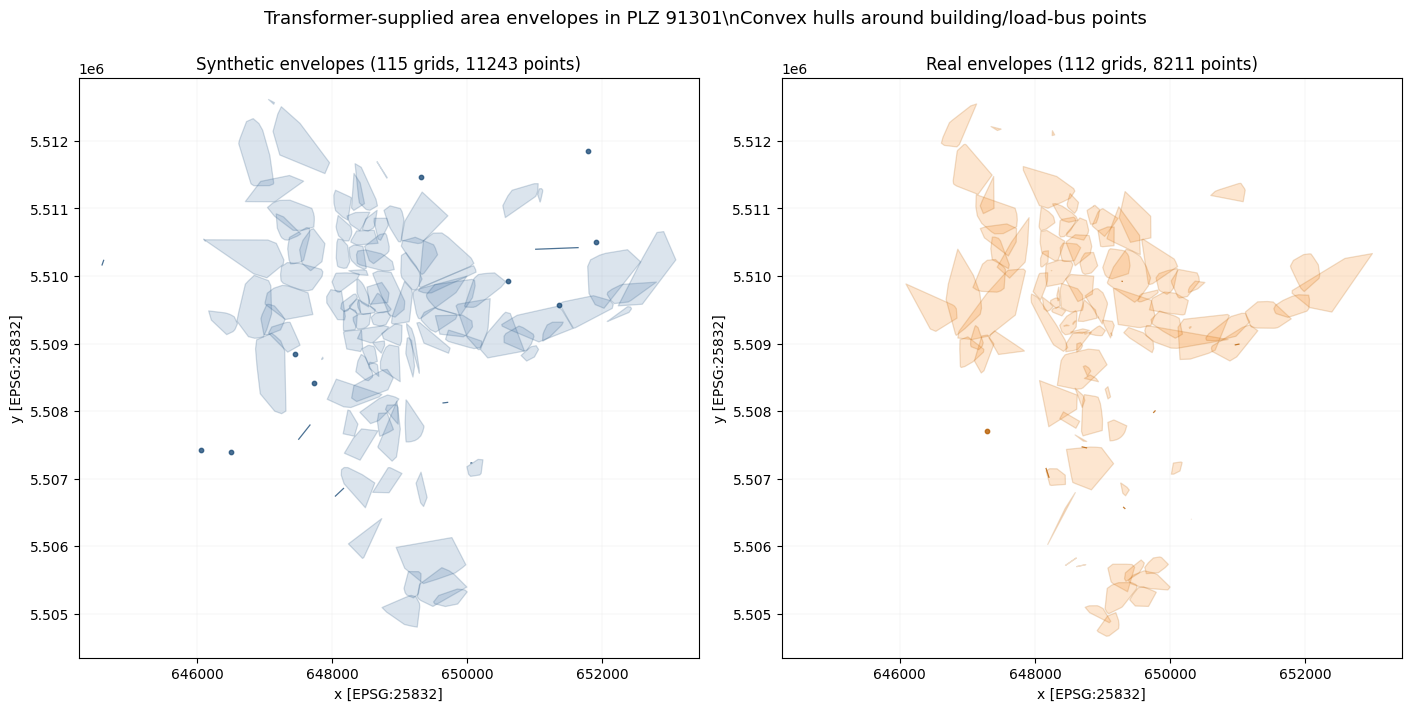

In [3]:
fig, axes, envelope_data = plot_grid_area_envelope_comparison(
    plz=PLZ,
    synthetic_run_name=SYNTHETIC_RUN_NAME,
    pylovo_version_id=PYLOVO_VERSION_ID,
    synthetic_building_use=SYNTHETIC_BUILDING_USE,
    real_grid_data_path=REAL_GRID_DATA_PATH,
    real_load_type=REAL_LOAD_TYPE,
    show_points=False,
    output_path=OUTPUT_PATH,
)
OUTPUT_PATH

In [4]:
envelope_data["synthetic_envelopes"].describe(include="all")

,grid_id,n_points,has_polygon
count,115,115.000000,115
unique,115,NaN,2
top,11891,NaN,True
freq,1,NaN,100
mean,NaN,97.765217,NaN
std,NaN,93.076400,NaN
min,NaN,1.000000,NaN
25%,NaN,18.000000,NaN
50%,NaN,70.000000,NaN
75%,NaN,146.000000,NaN


In [5]:
envelope_data["real_envelopes"].describe(include="all")

,grid_id,n_points,has_polygon
count,112,112.000000,112
unique,112,NaN,2
top,028,NaN,True
freq,1,NaN,104
mean,NaN,73.312500,NaN
std,NaN,70.149523,NaN
min,NaN,1.000000,NaN
25%,NaN,11.500000,NaN
50%,NaN,58.000000,NaN
75%,NaN,118.250000,NaN


## Optional filters

Use the default cells above for the HH+GHD diagnostic envelope comparison. For the previous HH-only view, set `SYNTHETIC_BUILDING_USE = "Residential"`, `REAL_LOAD_TYPE = "HH"`, and use a separate output filename.

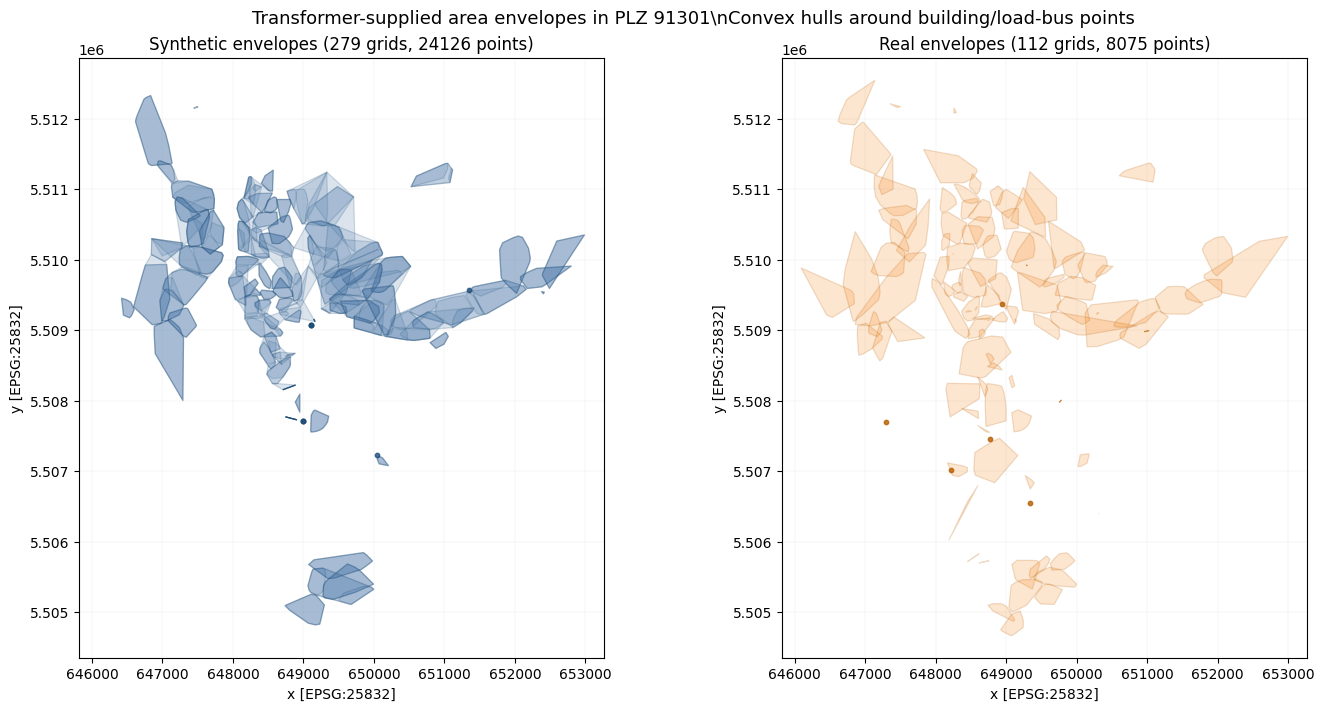

In [6]:
fig_hh, axes_hh, envelope_data_hh = plot_grid_area_envelope_comparison(
    plz=PLZ,
    synthetic_run_name=SYNTHETIC_RUN_NAME,
    synthetic_building_use="Residential",
    real_grid_data_path=REAL_GRID_DATA_PATH,
    real_load_type="HH",
    show_points=False,
    output_path=STEP5_DIR / "output" / "plots" / "grid_area_envelopes" / "synthetic_real_hh.png",
)